# CIPT Tutorial - Control-Induced Phase Transition

This tutorial demonstrates the **Control-Induced Phase Transition (CIPT)** in a 1D quantum circuit with conditional Reset/Haar gates on staircase geometries.

## What is CIPT?

The CIPT arises from a competition between two processes:

1. **Reset gates** (probability p_ctrl): Project qubit to |0> following Born rule, moving LEFT along the chain
2. **Haar random unitaries** (probability 1-p_ctrl): Entangle neighboring qubits, moving RIGHT along the chain


- **Reset-dominated phase** ( p_ctrl>0.5): Magnetization Mz -> +1 (qubits reset to |0>)
- **Unitary-dominated phase** ( p_ctrl<0.5): Magnetization Mz -> 0 (random state)

## Observable: Magnetization

We track the average magnetization:

$$M_z = \frac{1}{L} \sum_{i=1}^{L} \langle Z_i \rangle$$

where $\langle Z_i \rangle$ is the expectation value of the Pauli-Z operator on site $i$.

## Circuit Structure

Each timestep consists of one stochastic operation:

- With probability `p_ctrl`: Apply `Reset()` on `StaircaseLeft(1)` (moves left)
- With probability `1 - p_ctrl`: Apply `HaarRandom()` on `StaircaseRight(1)` (moves right)

The two staircases sweep in opposite directions, creating the spatial competition that drives the phase transition.

## Setup

First, activate the project environment and import QuantumCircuitsMPS:

In [1]:
using Pkg; Pkg.activate(dirname(@__DIR__))
using QuantumCircuitsMPS
using Printf
using Statistics
using Plots
using ProgressMeter
using Luxor

  Activating project at `~/personal/QuantumCircuitsMPS.jl`


## Section 1: Setup and Parameters

Define the system parameters for the CIPT simulation:

In [2]:
# Define system parameters
const L = 8                    # System size (number of qubits)
const bc = :periodic           # Boundary conditions
const n_steps = 2 * L^2        # Total timesteps (staircase sweeps)
const p_ctrl = 0.5             # Control probability

println("Parameters:")
println("  L = $L (system size)")
println("  bc = $bc (boundary conditions)")
println("  n_steps = $n_steps (circuit timesteps)")
println("  p_ctrl = $p_ctrl (control probability)")

Parameters:
  L = 8 (system size)
  bc = periodic (boundary conditions)
  n_steps = 128 (circuit timesteps)
  p_ctrl = 0.5 (control probability)


## Section 2: Building the CIPT Circuit

The circuit implements the CIPT protocol with stochastic Reset/Haar gates on opposing staircase geometries.


In [3]:
# Build circuit: at each step, coin flip decides Reset (left) or Haar (right)
left = StaircaseLeft(1)
right = StaircaseRight(1)

circuit = Circuit(L=L, bc=bc, p_ctrl=p_ctrl) do c
    apply_with_prob!(c; rng=:gates_spacetime, outcomes=[
        (probability=c.params[:p_ctrl], gate=Reset(), geometry=left),
        (probability=1-c.params[:p_ctrl], gate=HaarRandom(), geometry=right)
    ])
end

println("Circuit built successfully")
println("  System size: $(circuit.L) qubits")
println("  Boundary conditions: $(circuit.bc)")

Circuit built successfully
  System size: 8 qubits
  Boundary conditions: periodic
  System size: 8 qubits
  Boundary conditions: periodic


### Circuit Visualization

Visualize the circuit structure to inspect the gate layout before running the simulation:

In [ ]:
plot_circuit(circuit; gates_spacetime=42, n_steps=6)

## Section 3: Simulation with Magnetization Tracking

We track the **magnetization** $M_z = (1/L) \sum_i \langle Z_i \rangle$ 



In [10]:
println("Running simulation...")
println()

# Create simulation state with RNG registry
state = SimulationState(
    L=L,
    bc=bc,
    maxdim=64,
    rng=RNGRegistry(gates_spacetime=42, born_measurement=1, gates_realization=2)
)

# Initialize to product state |0>^L
initialize!(state, ProductState(binary_int=0))

# Track magnetization
track!(state, :Mz => Magnetization(:Z))

# Run simulation: n_steps controls how many times the circuit do-block runs
# record_when=:every_gate records after each gate (1 gate per step)
simulate!(circuit, state; n_steps=n_steps, record_when=:every_gate)

# Extract magnetization values
mz_vals = state.observables[:Mz]

println("Simulation complete")
println("  Recorded $(length(mz_vals)) magnetization values")
println("  Initial Mz = $(Printf.@sprintf("%.4f", mz_vals[1]))")
println("  Final   Mz = $(Printf.@sprintf("%.4f", mz_vals[end]))")

Running simulation...

Simulation complete
  Recorded 128 magnetization values
  Initial Mz = 0.8079
  Final   Mz = 0.7570


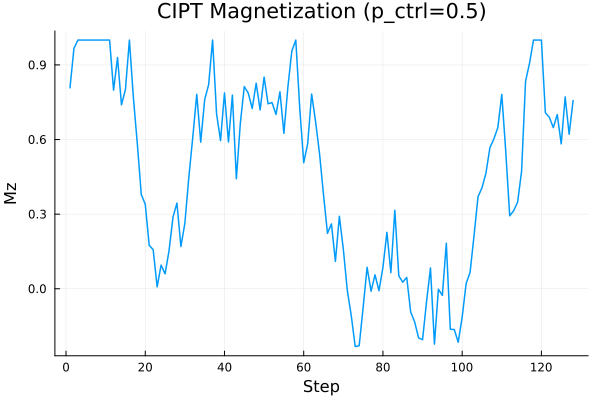

In [11]:
plot(mz_vals, xlabel="Step", ylabel="Mz", title="CIPT Magnetization (p_ctrl=$p_ctrl)",
     legend=false, lw=1.5)

## Section 4: Steady-State Phase Diagram

Sweep `p_ctrl` to map out the phase diagram: steady-state Mz as a function of control probability for multiple system sizes.

Each point is averaged over `ensemble_size` random seeds.

In [19]:
function run_cipt(; L, p_ctrl, seed, bc=:periodic, n_steps=L^2, maxdim=2^20)
    left = StaircaseLeft(1)
    right = StaircaseRight(1)

    circuit = Circuit(L=L, bc=bc, p_ctrl=p_ctrl) do c
        apply_with_prob!(c; rng=:gates_spacetime, outcomes=[
            (probability=c.params[:p_ctrl], gate=Reset(), geometry=left),
            (probability=1-c.params[:p_ctrl], gate=HaarRandom(), geometry=right)
        ])
    end

    state = SimulationState(L=L, bc=bc, maxdim=maxdim,cutoff = 1e-6,
        rng=RNGRegistry(gates_spacetime=seed, born_measurement=seed+100, gates_realization=seed+200))
    initialize!(state, ProductState(binary_int=0))
    track!(state, :Mz => Magnetization(:Z))

    simulate!(circuit, state; n_steps=n_steps, record_when=:final_only)
    return state.observables[:Mz][end]
end

run_cipt (generic function with 1 method)

In [20]:
# Sweep parameters
L_list = [4, 6,8,10,12]
p_list = 0.1:0.1:0.9 |> collect
# p_list = 0.4:0.02:0.6 |> collect
ensemble_size = 100

configs = [(L=L, p=p, seed=s) for L in L_list for p in p_list for s in 1:ensemble_size]
raw = Vector{Float64}(undef, length(configs))

# Run with `julia -t auto` for multithreaded execution
println("Running $(length(configs)) configs on $(Threads.nthreads()) threads...")
@time @showprogress Threads.@threads for i in eachindex(configs)
    c = configs[i]
    raw[i] = run_cipt(L=c.L, p_ctrl=c.p, seed=c.seed)
end

# Reshape to (seed, p, L) and average over seeds
ns, np, nL = ensemble_size, length(p_list), length(L_list)
Mz_raw = reshape(raw, ns, np, nL)
Mz_mean = dropdims(mean(Mz_raw, dims=1), dims=1)
Mz_sem  = dropdims(std(Mz_raw, dims=1), dims=1) ./ sqrt(size(Mz_raw, 1))

println("Done!")

Running 4500 configs on 6 threads...


Progress: 100%|█████████████████████████████████████████| Time: 0:05:03


303.855820 seconds (1.67 G allocations: 397.339 GiB, 21.02% gc time, 275 lock conflicts, 0.10% compilation time)
Done!


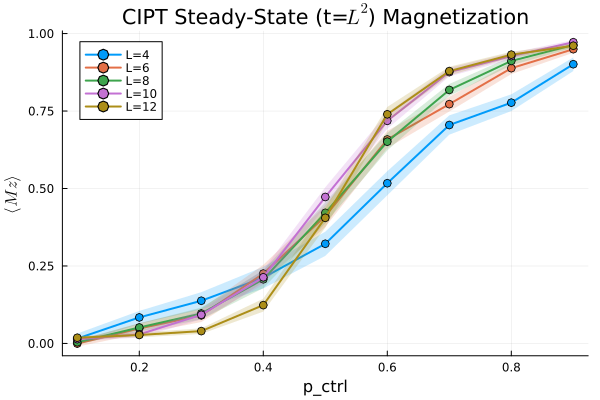

In [21]:
p_fig = plot(xlabel="p_ctrl", ylabel=raw"$\langle Mz \rangle$", title=raw"CIPT Steady-State (t=$L^2$) Magnetization", legend=:topleft)
for (iL, L) in enumerate(L_list)
    plot!(p_fig, p_list, Mz_mean[:, iL], ribbon=Mz_sem[:, iL], fillalpha=0.2,
          label="L=$L", lw=2, marker=:o, ms=4)
end
p_fig

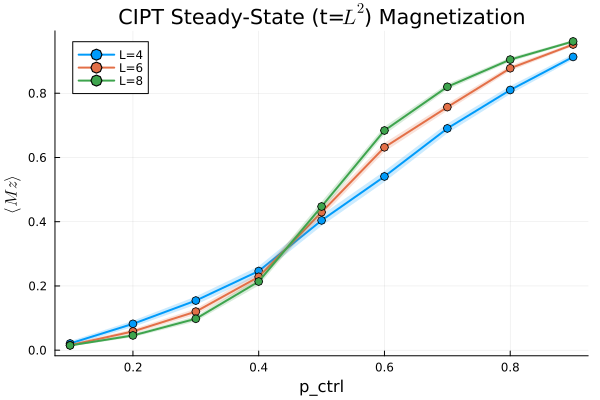

In [ ]:
p_fig = plot(xlabel="p_ctrl", ylabel=raw"$\langle Mz \rangle$", title=raw"CIPT Steady-State (t=$L^2$) Magnetization", legend=:topleft)
for (iL, L) in enumerate(L_list)
    plot!(p_fig, p_list, Mz_mean[:, iL], ribbon=Mz_sem[:, iL], fillalpha=0.2,
          label="L=$L", lw=2, marker=:o, ms=4)
end
p_fig

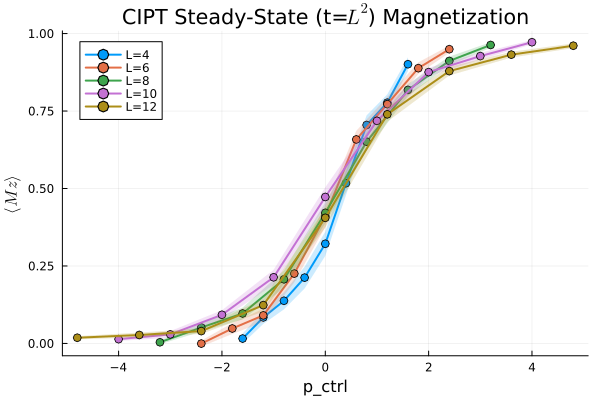

In [23]:
p_fig = plot(xlabel="p_ctrl", ylabel=raw"$\langle Mz \rangle$", title=raw"CIPT Steady-State (t=$L^2$) Magnetization", legend=:topleft)
for (iL, L) in enumerate(L_list)
    plot!( p_fig  , (p_list .- 0.5) * L, Mz_mean[:, iL], ribbon=Mz_sem[:, iL], fillalpha=0.2,
          label="L=$L", lw=2, marker=:o, ms=4)
end
p_fig